In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot
import gc
import helpers.stc_helper as stc_helper
import time
from pycircstat2.hypothesis import rayleigh_test
from mne.stats import permutation_t_test
from mne.stats import fdr_correction


ss = hf.settings_dict()

In [2]:
results_dir = Path(ss["results_dir"])
alpha     = 0.05   # significance threshold
figsize = (12,5)
dpi = 100
cut_coords = (0,0)

  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
  Significant voxels: 36 / 3031
  Brain activation percentage: 1.187726822830749%
  Significant voxels: 11 / 3031
  Brain activation percentage: 0.3629165291982844%
  Significant voxels: 1 / 3031
  Brain activation percentage: 0.03299241174529858%
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
    Reading a source space...
    [done]
    1 source spaces read


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/stc_helper.py:177: UserWarning: empty mask
  plot_stat_map(


<Figure size 1200x500 with 0 Axes>

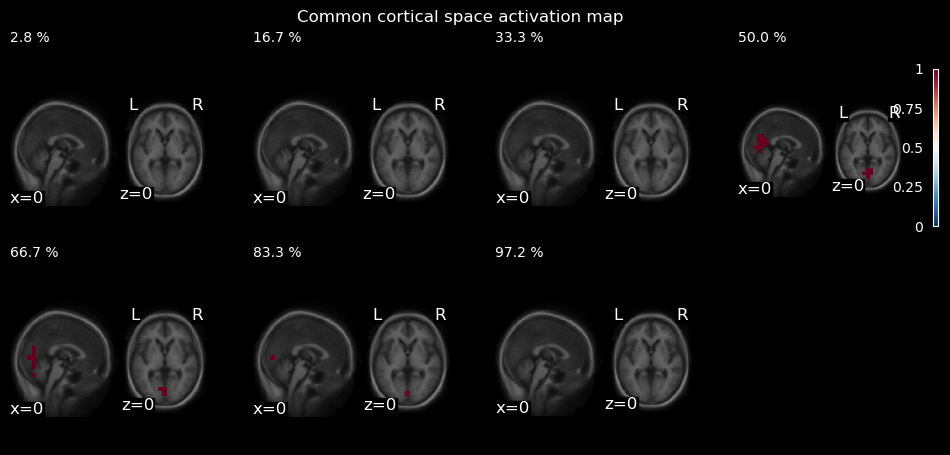

In [3]:
# loop over each event type
fh = plt.figure(figsize=figsize)
act_percent = []
act_stcs = []
titles = []
for event_id in ss['event_id_list']:
        event_name = str(event_id)
        duty_cycle = ss['event_name_list'][event_id-1]
        event_dir = results_dir / event_name
        atlas_stc_file = event_dir / f"group-event-{event_name}-puncorr-fsaverage-vol-vl.stc"

        stc = mne.read_source_estimate(atlas_stc_file)

        p_vals  = stc.data[:, 0]

        n_sig = (p_vals < alpha).sum()
        print(f"  Significant voxels: {n_sig} / {len(p_vals)}")
        print(f"  Brain activation percentage: {(n_sig/len(p_vals))*100}%")

        sig_stc = stc.copy()
        sig_stc.data = (p_vals < alpha).astype(float)[:, np.newaxis]

        act_stcs.append(sig_stc)

        act_percent.append((n_sig/len(p_vals))*100)

        titles.append(f"{ss['event_name_list'][event_id-1]} %")


fsaverage_src_file = Path(ss["fs_subjects_dir"])  / "fsaverage" / "bem" / "fsaverage-vol-10-src.fif"

fsaverage_src = mne.read_source_spaces(str(fsaverage_src_file))

t1 = op.join(ss["fs_subjects_dir"], "fsaverage", 'mri', 'T1.mgz')

stc_helper.plot_stc2(
    stcs=act_stcs,
    src=fsaverage_src,
    t1=t1,
    display_mode="xz",
    title=f'Common cortical space activation map',
    fig_titles=titles,
    nrows=2,
    ncols=4,
    figsize=figsize,
    cut_coords=cut_coords,
    dpi=dpi,
    )

/tmp/ipykernel_264183/3154426824.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ss['event_name_list'], rotation=45)


Text(0, 0.5, 'Brain response volume (% of brain)')

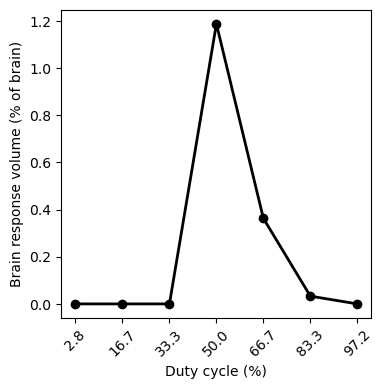

In [4]:


x = [float(event_name) for event_name in ss['event_name_list']]
x = range(7)
fig, ax = plt.subplots(figsize=(4, 4))

plt.plot(x, act_percent, '-o', c='k', lw=2)

ax.set_xlabel('Duty cycle (%)')
ax.set_xticklabels(ss['event_name_list'], rotation=45)
ax.set_xticks(x)
ax.set_ylabel('Brain response volume (% of brain)')

